In [1]:
import sys
from pathlib import Path

# Insert repo root directory into notebook path to allow for import with the repo directory
repository_root = Path.cwd().parent.parent.resolve()
sys.path.insert(0, str(repository_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from land_cover_change.config.config import resolved_config
from land_cover_change.data_access.raster import (
    discover_lulc_rasters,
    extract_raster_map_metadata,
)
from land_cover_change.services.class_area import (
    build_area_comparison,
    build_class_area_table,
    calculate_percentage_changes,
)
from land_cover_change.services.raster import (
    calculate_pixel_area,
    prepare_analysis_raster,
    validate_raster_alignment,
)
from land_cover_change.services.transition import (
    calculate_transition_matrix,
    summarize_transitions,
    transition_areas,
    transition_percentages,
)
from land_cover_change.utils.utils import extract_year

In [3]:
# Discover the annual rasters and verify that they share one source grid.
geotif_dir = Path(resolved_config.dataset.raw_dataset.aoi_lulc)
geotif_data_path = discover_lulc_rasters(geotif_dir)
validate_raster_alignment(geotif_data_path)

raster_metadata_table = pd.DataFrame(
    [
        {
            "raster_name": raster_path.name,
            **extract_raster_map_metadata(raster_path),
        }
        for raster_path in geotif_data_path
    ]
).set_index("raster_name")

raster_metadata_table

,coordinate_reference_system,shape,resolution,bounds,band_count,data_types,transform,nodata
raster_name,,,,,,,,
lulc_2016_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0
lulc_2020_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0
lulc_2025_jan_feb.tif,"(proj, datum, no_defs)","(950, 1053)","(8.983152841195215e-05, 8.983152841195215e-05)","(5.638725038418237, 6.368875701350584, 5.73331...",1,"(uint8,)","(8.983152841195215e-05, 0.0, 5.638725038418237...",255.0


In [4]:
# Prepare each categorical raster once for projected area analysis.
analysis_rasters = {
    extract_year(raster_path): prepare_analysis_raster(raster_path)
    for raster_path in geotif_data_path
}

for raster_path in geotif_data_path:
    year = extract_year(raster_path)
    analysis_raster = analysis_rasters[year]
    land_cover = analysis_raster.data

    print(f"-----------------{raster_path.stem}--------------------")
    print("Shape:", land_cover.shape)
    print("Total pixels:", land_cover.size)
    print("Valid pixels:", land_cover.count())
    print("Masked pixels:", np.ma.count_masked(land_cover))
    print(
        "Are all pixels masked?",
        np.ma.getmaskarray(land_cover).all(),
    )
    print("Valid class values:", np.unique(land_cover.compressed()))
    print(
        "Pixel area in square metres:",
        calculate_pixel_area(analysis_raster.transform),
    )

-----------------lulc_2016_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 3 4 5 6 7]
Pixel area in square metres: 98.86630544456712
-----------------lulc_2020_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 3 4 5 6 7]
Pixel area in square metres: 98.86630544456712
-----------------lulc_2025_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 4 5 6]
Pixel area in square metres: 98.86630544456712


In [5]:
# Build the reusable long-form class-area table.
dynamic_world_classes = resolved_config.dynamic_world.classes
class_values = list(dynamic_world_classes)
class_names = {
    class_value: class_definition.name
    for class_value, class_definition in dynamic_world_classes.items()
}

class_area_table = build_class_area_table(
    geotif_data_path,
    class_values,
)
class_area_table.insert(
    2,
    "class_name",
    class_area_table["class_value"].map(class_names),
)

In [6]:
class_area_table

,year,class_value,class_name,pixel_count,area_km2,class_percentage
0,2016,0,water,738,0.072963,0.126169
1,2016,1,trees,314187,31.062508,53.713699
2,2016,2,grass,782,0.077313,0.133691
3,2016,3,flooded vegetation,446,0.044094,0.076249
4,2016,4,crops,3482,0.344252,0.595286
5,2016,5,shrub and scrub,39191,3.874669,6.700129
6,2016,6,built area,224005,22.146547,38.296101
7,2016,7,bare ground,2098,0.207422,0.358676
8,2016,8,snow and ice,0,0.000000,0.000000
9,2020,0,water,322,0.031835,0.055049


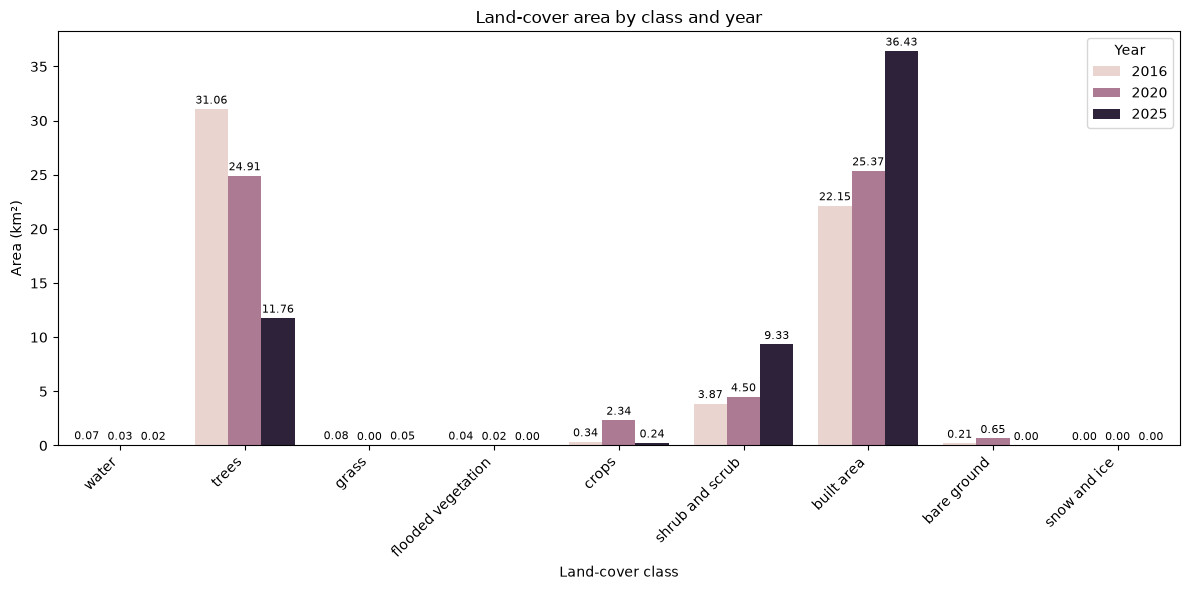

In [7]:
# Visualise land-cover area by class and year.
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=class_area_table,
    x="class_name",
    y="area_km2",
    hue="year",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8,
    )

ax.set(
    xlabel="Land-cover class",
    ylabel="Area (km²)",
    title="Land-cover area by class and year",
)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [8]:
# Build the comparison data with the service, then style a display copy.
area_comparison = build_area_comparison(class_area_table)
area_comparison_display = (
    area_comparison
    .rename(index=class_names)
    .rename_axis(
        index="Land-cover class",
        columns=["Measurement", "Year"],
    )
)

area_subset = pd.IndexSlice[:, pd.IndexSlice["area_km2", :]]
percentage_subset = pd.IndexSlice[
    :,
    pd.IndexSlice["class_percentage", :],
]
area_max = area_comparison_display["area_km2"].to_numpy().max()
percentage_max = (
    area_comparison_display["class_percentage"].to_numpy().max()
)
formatters = {
    column: "{:.4f}" if column[0] == "area_km2" else "{:.2f}%"
    for column in area_comparison_display.columns
}

visual_table = (
    area_comparison_display.style
    .format(formatters)
    .background_gradient(
        cmap="Greens",
        axis=0,
        subset=area_subset,
        vmin=0,
        vmax=area_max,
    )
    .background_gradient(
        cmap="Blues",
        axis=0,
        subset=percentage_subset,
        vmin=0,
        vmax=percentage_max,
    )
    .set_caption("Land-cover area and percentage by class and year")
    .set_table_attributes('style="width: 70%; table-layout: fixed;"')
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("min-width", "80px"),
                    ("padding", "9px"),
                    ("font-size", "13px"),
                    ("text-align", "center"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "9px"),
                    ("font-size", "12px"),
                    ("text-align", "center"),
                ],
            },
            {
                "selector": "caption",
                "props": [
                    ("font-size", "13px"),
                    ("font-weight", "bold"),
                    ("padding", "12px"),
                ],
            },
        ]
    )
)

display(visual_table)

In [9]:
# Calculate chronological percentage changes with the service.
percentage_change = (
    calculate_percentage_changes(area_comparison)
    .rename(index=class_names)
    .rename_axis(
        index="Land-cover class",
        columns="Period",
    )
)

In [10]:
percentage_change_table = (
    percentage_change.style
    .format("{:+.2f}%")
    .bar(
        align="zero",
        color=["#d65f5f", "#5fba7d"],
    )
    .set_caption("Percentage change in land-cover area")
    .set_table_attributes('style="width: 100%; table-layout: fixed;"')
)

display(percentage_change_table)

Period,2016–2020,2020–2025,2016–2025
Land-cover class,,,
water,-56.37%,-27.95%,-68.56%
trees,-19.79%,-52.78%,-62.13%
grass,-93.99%,+1036.17%,-31.71%
flooded vegetation,-51.57%,-100.00%,-100.00%
crops,+579.72%,-89.91%,-31.39%
shrub and scrub,+16.16%,+107.23%,+140.72%
built area,+14.54%,+43.60%,+64.48%
bare ground,+213.68%,-100.00%,-100.00%
snow and ice,+nan%,+nan%,+nan%


In [11]:
# Select any two available years for pairwise transition analysis.
earlier_year = 2016
later_year = 2020

if earlier_year >= later_year:
    raise ValueError("earlier_year must be less than later_year")

missing_years = {earlier_year, later_year}.difference(analysis_rasters)
if missing_years:
    raise ValueError(
        f"No prepared rasters found for years: {sorted(missing_years)}"
    )

earlier_raster = analysis_rasters[earlier_year]
later_raster = analysis_rasters[later_year]
transition_counts = calculate_transition_matrix(
    earlier_raster.data,
    later_raster.data,
    class_values,
)
transition_counts_display = (
    transition_counts
    .rename(index=class_names, columns=class_names)
    .rename_axis(
        index=f"from class ({earlier_year})",
        columns=f"to class ({later_year})",
    )
)

transition_counts_display

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,264,294,1,86,5,49,39,0,0
trees,52,232495,0,59,13260,32148,34368,1805,0
grass,0,503,46,0,0,233,0,0,0
flooded vegetation,0,97,0,52,36,24,237,0,0
crops,0,724,0,0,1189,395,1076,98,0
shrub and scrub,0,14266,0,19,4478,9518,9572,1338,0
built area,6,3540,0,0,4540,3111,209468,3340,0
bare ground,0,75,0,0,160,47,1816,0,0
snow and ice,0,0,0,0,0,0,0,0,0


In [12]:
pixel_area_m2 = calculate_pixel_area(earlier_raster.transform)
transition_area_km2 = transition_areas(
    transition_counts,
    pixel_area_m2,
)
transition_area_display = (
    transition_area_km2
    .rename(index=class_names, columns=class_names)
    .rename_axis(
        index=f"from class ({earlier_year})",
        columns=f"to class ({later_year})",
    )
)

transition_area_display

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,0.026101,0.029067,0.000099,0.008503,0.000494,0.004844,0.003856,0.000000,0.0
trees,0.005141,22.985922,0.000000,0.005833,1.310967,3.178354,3.397837,0.178454,0.0
grass,0.000000,0.049730,0.004548,0.000000,0.000000,0.023036,0.000000,0.000000,0.0
flooded vegetation,0.000000,0.009590,0.000000,0.005141,0.003559,0.002373,0.023431,0.000000,0.0
crops,0.000000,0.071579,0.000000,0.000000,0.117552,0.039052,0.106380,0.009689,0.0
shrub and scrub,0.000000,1.410427,0.000000,0.001878,0.442723,0.941009,0.946348,0.132283,0.0
built area,0.000593,0.349987,0.000000,0.000000,0.448853,0.307573,20.709327,0.330213,0.0
bare ground,0.000000,0.007415,0.000000,0.000000,0.015819,0.004647,0.179541,0.000000,0.0
snow and ice,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [13]:
transition_percentage = transition_percentages(transition_counts)
transition_percentage_display = (
    transition_percentage
    .rename(index=class_names, columns=class_names)
    .rename_axis(
        index=f"from class ({earlier_year})",
        columns=f"to class ({later_year})",
    )
)

transition_percentage_display

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,35.772358,39.837398,0.135501,11.653117,0.677507,6.639566,5.284553,0.000000,0.0
trees,0.016551,73.998924,0.000000,0.018779,4.220417,10.232123,10.938708,0.574499,0.0
grass,0.000000,64.322251,5.882353,0.000000,0.000000,29.795396,0.000000,0.000000,0.0
flooded vegetation,0.000000,21.748879,0.000000,11.659193,8.071749,5.381166,53.139013,0.000000,0.0
crops,0.000000,20.792648,0.000000,0.000000,34.147042,11.344055,30.901781,2.814474,0.0
shrub and scrub,0.000000,36.401215,0.000000,0.048481,11.426093,24.286188,24.423975,3.414049,0.0
built area,0.002679,1.580322,0.000000,0.000000,2.026740,1.388808,93.510413,1.491038,0.0
bare ground,0.000000,3.574833,0.000000,0.000000,7.626311,2.240229,86.558627,0.000000,0.0
snow and ice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
transition_summary = summarize_transitions(transition_area_km2)
transition_summary_display = (
    transition_summary
    .rename(index=class_names)
    .rename_axis(index=f"class ({earlier_year}–{later_year})")
)

In [15]:
transition_summary_display

,earlier_area_km2,later_area_km2,persistence_km2,gain_km2,loss_km2,net_change_km2,total_change_km2
class (2016–2020),,,,,,,
water,0.072963,0.031835,0.026101,0.005734,0.046863,-0.041128,0.052597
trees,31.062508,24.913716,22.985922,1.927794,8.076586,-6.148792,10.004380
grass,0.077313,0.004647,0.004548,0.000099,0.072766,-0.072667,0.072864
flooded vegetation,0.044094,0.021355,0.005141,0.016214,0.038953,-0.022739,0.055167
crops,0.344252,2.339968,0.117552,2.222416,0.226700,1.995715,2.449116
shrub and scrub,3.874669,4.500889,0.941009,3.559879,2.933660,0.626219,6.493539
built area,22.146547,25.366721,20.709327,4.657394,1.437219,3.220174,6.094613
bare ground,0.207422,0.650639,0.000000,0.650639,0.207422,0.443218,0.858061
snow and ice,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
